# RG3 모델 비교 — 가능한 모델을 모두 시도해 성능 끌어올리기

`RG33.ipynb`(데이터 진단 · 이상탐지 · 검사 우선순위)에 이어, **지도학습 · 불균형 대응 · 이상탐지 · 튜닝 · 앙상블**을 같은 교차검증으로 비교한다.
계산은 `run_models.py`(모델 정의는 `model_zoo.py`)가 하고, 이 노트북은 결과를 읽어 해석한다.

| 구분 | 지표 | 계산 |
|---|---|---|
| **주 지표** | **PR-AUC**, **Recall@k%** (k = 10, 20, 30) | 평가 fold별 → 50개 fold 평균 ± 표준편차 |
| **손익 분석용** | **검사율@재현율** (0.9, 1.0) | fold당 불량이 4~5개라 fold 안에서는 0.9 = 1.0이 된다 → 반복마다 5개 fold 점수를 fold 안 백분위로 바꿔 모은 뒤 불량 전체로 계산 (10회 평균 ± 표준편차) |
| 참고 | F1, Recall, Precision, ROC-AUC | F1·Recall·Precision의 임계값은 **학습 fold 안 3-fold 예측**에서 F1 최대점으로 정함 (평가 fold 미사용) |

## 1. 평가 설계

**평가 두 가지** — `RG33.ipynb`에서 불량 25개 중 23개가 쌍의 앞쪽 부품(`pair_pos = 0`)이고, 공정 값은 불량 샷과 양품 샷을 구분하지 못했다(4-2, 6-6).
전체 평가에서는 `pair_pos`가 성능 대부분을 만들므로, **공정 값이 불량을 가려내는지**는 부품 위치를 고정한 E2로 판정한다.

| 평가 | 데이터 | 역할 |
|---|---|---|
| **E2 앞쪽 부품 안** | `pair_pos = 0` 부품만 (591부품 = 591샷, 불량 23), 같은 분할 방식 | **판정용** — 가장 강한 비공정 신호(부품 위치)를 뺀 평가. "앞쪽 부품 중에서 공정 값으로 불량을 더 골라낼 수 있는가" |
| E1 전체 기간 | labeled 1,182부품 (591샷), `shot_id` 묶음 층화 5-fold × 10회 (`RG33.ipynb` 5-1과 같은 분할) | 참고 (팀 공통 방식) — 쌍 순서 규칙과의 비교 |

> RG3 전용 설계: 불량이 기간 전체에 흩어져 있어(샷 68~566, `RG33.ipynb` 8-2 b) "불량 시기 안" 평가는 의미가 없다. 대신 RG3에서 가장 강한 비공정 신호인 **부품 위치를 고정**한다.

**기준선** — 모델이 넘어야 할 선
- 무작위 / 쌍 순서 규칙(앞쪽 부품 위험, E1만) / **샷 순서**(방향은 학습 fold에서 결정). 샷 순서를 넘지 못하면 모델은 공정 값이 아니라 **시간**을 맞힌 것이다.

**피처** — E1: 공정 값 23개 / 공정 값 23개 + `pair_pos`(쌍 순서, 해석 A: 부품 위치 가정). E2: 공정 값 23개 (`pair_pos`가 한 값뿐).

**누수 방지**
- 같은 샷의 두 부품(공정 값 동일)은 항상 같은 fold. 튜닝·스태킹·임계값의 **내부 CV도 샷 단위**로 묶는다 (sklearn `StackingClassifier`의 내부 CV는 샷을 묶지 않아 직접 구현).
- 표준화·오버샘플링(SMOTE·ADASYN)·언더샘플링은 학습 fold 안에서만.
- 튜닝은 **중첩 교차검증**: 학습 fold 안 3-fold로 후보 설정(최대 12개)의 PR-AUC를 비교해 고른다.

### 시도한 모델 (36종)

| 계열 | 모델 |
|---|---|
| 선형·확률 | 로지스틱 (L2 / L1 / ElasticNet), LDA (shrinkage), 나이브 베이즈 |
| 거리·커널·신경망 | kNN, SVM (선형 / RBF), MLP |
| 트리·부스팅 | 결정트리, 랜덤포레스트, 엑스트라트리, AdaBoost, GradientBoosting, HistGradientBoosting, XGBoost, LightGBM, CatBoost |
| 불균형 대응 | SMOTE + 로지스틱, ADASYN + 로지스틱, SMOTE + 랜덤포레스트, Balanced 랜덤포레스트, EasyEnsemble, RUSBoost |
| 이상탐지 (학습 fold 양품만 학습) | Isolation Forest, LOF, One-Class SVM, Elliptic Envelope |
| 튜닝 (중첩 CV) | 로지스틱, 랜덤포레스트, XGBoost, LightGBM, CatBoost |
| 앙상블 | 스태킹 (LR·SVM·RF → LR), 순위 평균 5종 (**사전 고정**: 로지스틱 L2·SVM RBF·랜덤포레스트·엑스트라트리·CatBoost), 부스팅 튜닝 3종 평균 (**사후 선택** → 낙관적일 수 있음) |

- 시도하지 못한 것: **TabPFN**(소표본 표 데이터용 사전학습 모델)은 가중치를 받으려면 사용자 계정의 라이선스 동의·로그인이 필요해 제외했다. 준지도학습은 unlabeled가 다른 기간·운전 조건이라(`RG33.ipynb` 3-6) 제외했다.
- 모델 기본 설정은 소표본·불균형에 맞춘 보수적 값으로 정하고, 결과를 보고 고치지 않았다 (XGBoost 불균형 가중치만 RG3 양품/불량 비 46).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if f in installed_fonts), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

C_MAIN, C_SUB = '#2a78d6', '#eb6834'
C_INK, C_GRID = '#52514e', '#e6e5e0'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': C_GRID, 'axes.labelcolor': C_INK,
    'xtick.color': C_INK, 'ytick.color': C_INK,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.6,
    'axes.titlesize': 10,
})

TABLES = Path('outputs/tables')
RUN = False  # True: 모델 비교를 다시 계산 (24코어 기준 약 28분). False: 저장된 결과 사용

if RUN:
    import run_models
    run_models.compare()
    run_models.time_increment()

summary = pd.read_csv(TABLES / 'model_summary.csv')
increment = pd.read_csv(TABLES / 'time_increment.csv', index_col=0)
EVALS = summary['eval'].unique().tolist()
print(EVALS)

['E1 전체 기간', 'E2 앞쪽 부품 안 (pair_pos=0)']


In [2]:
MAIN = ['PR-AUC', 'Recall@10%', 'Recall@20%', 'Recall@30%']
COST = ['검사율@재현율0.9', '검사율@재현율1']
REF = ['F1', 'Recall', 'Precision', 'ROC-AUC']


def table(eval_name, features):
    """한 설정의 결과표 (기준선 포함, PR-AUC 내림차순). 값 = 평균 ± 표준편차"""
    d = summary[(summary['eval'] == eval_name) & summary['features'].isin([features, '-'])].copy()
    d = d.sort_values('PR-AUC_mean', ascending=False).set_index('model')
    out = pd.DataFrame({m: d[f'{m}_mean'].map('{:.3f}'.format) + ' ± ' + d[f'{m}_std'].map('{:.3f}'.format)
                        for m in MAIN + COST + REF})
    out.insert(0, '계열', d['family'])
    if d['failed_folds'].sum():
        out['학습 실패 fold'] = d['failed_folds']
    return out

## 2. E2 앞쪽 부품 안 (판정용)

`pair_pos = 0` 부품만 쓰므로 피처는 공정 값 23개 하나다 (쌍 순서 규칙 기준선도 없음).

In [3]:
table(EVALS[1], '공정 값 23')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
XGBoost,부스팅,0.096 ± 0.061,0.167 ± 0.159,0.283 ± 0.173,0.404 ± 0.193,0.882 ± 0.050,0.934 ± 0.065,0.089 ± 0.069,0.395 ± 0.320,0.063 ± 0.085,0.552 ± 0.110,0
SMOTE + 랜덤포레스트,불균형,0.095 ± 0.064,0.136 ± 0.143,0.249 ± 0.205,0.336 ± 0.252,0.830 ± 0.054,0.912 ± 0.048,0.063 ± 0.057,0.380 ± 0.383,0.040 ± 0.043,0.541 ± 0.135,0
랜덤포레스트 (튜닝),튜닝,0.095 ± 0.070,0.148 ± 0.150,0.249 ± 0.213,0.336 ± 0.212,0.837 ± 0.038,0.908 ± 0.031,0.065 ± 0.074,0.378 ± 0.407,0.057 ± 0.145,0.535 ± 0.130,0
LightGBM,부스팅,0.088 ± 0.055,0.167 ± 0.169,0.276 ± 0.190,0.359 ± 0.192,0.850 ± 0.054,0.945 ± 0.038,0.073 ± 0.064,0.428 ± 0.361,0.046 ± 0.052,0.554 ± 0.109,0
부스팅 튜닝 3종 평균 (사후 선택),앙상블,0.087 ± 0.059,0.140 ± 0.158,0.252 ± 0.198,0.362 ± 0.202,0.853 ± 0.066,0.944 ± 0.042,0.054 ± 0.049,0.427 ± 0.403,0.030 ± 0.030,0.527 ± 0.113,0
CatBoost,부스팅,0.084 ± 0.049,0.140 ± 0.161,0.275 ± 0.196,0.393 ± 0.197,0.868 ± 0.047,0.962 ± 0.027,0.065 ± 0.053,0.406 ± 0.368,0.039 ± 0.041,0.555 ± 0.100,0
랜덤포레스트,트리,0.082 ± 0.057,0.125 ± 0.146,0.212 ± 0.183,0.327 ± 0.206,0.824 ± 0.053,0.931 ± 0.056,0.056 ± 0.046,0.424 ± 0.400,0.031 ± 0.027,0.536 ± 0.122,0
XGBoost (튜닝),튜닝,0.080 ± 0.047,0.154 ± 0.144,0.224 ± 0.167,0.321 ± 0.192,0.868 ± 0.051,0.946 ± 0.043,0.056 ± 0.047,0.455 ± 0.413,0.035 ± 0.048,0.510 ± 0.117,0
HistGradientBoosting,부스팅,0.080 ± 0.042,0.144 ± 0.148,0.258 ± 0.191,0.340 ± 0.201,0.823 ± 0.050,0.958 ± 0.030,0.054 ± 0.053,0.345 ± 0.360,0.032 ± 0.034,0.553 ± 0.116,0


## 3. E1 전체 기간 (참고)

In [4]:
table(EVALS[0], '공정 값 23')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
[기준] 쌍 순서 규칙,기준선,0.072 ± 0.047,0.216 ± 0.180,0.400 ± 0.206,0.556 ± 0.226,0.480 ± 0.019,0.821 ± 0.095,0.075 ± 0.009,0.920 ± 0.107,0.039 ± 0.005,0.723 ± 0.084,0
HistGradientBoosting,부스팅,0.049 ± 0.041,0.132 ± 0.138,0.228 ± 0.162,0.332 ± 0.192,0.880 ± 0.050,0.956 ± 0.048,0.031 ± 0.032,0.260 ± 0.316,0.018 ± 0.020,0.509 ± 0.114,0
LightGBM,부스팅,0.049 ± 0.030,0.160 ± 0.140,0.292 ± 0.177,0.388 ± 0.183,0.886 ± 0.034,0.969 ± 0.042,0.036 ± 0.045,0.212 ± 0.298,0.022 ± 0.029,0.550 ± 0.109,0
XGBoost,부스팅,0.048 ± 0.039,0.120 ± 0.121,0.272 ± 0.165,0.360 ± 0.190,0.882 ± 0.061,0.986 ± 0.010,0.039 ± 0.044,0.328 ± 0.340,0.025 ± 0.040,0.530 ± 0.106,0
[기준] 무작위,기준선,0.047 ± 0.050,0.100 ± 0.116,0.204 ± 0.174,0.308 ± 0.233,0.872 ± 0.072,0.959 ± 0.038,0.041 ± 0.058,0.240 ± 0.318,0.032 ± 0.068,0.515 ± 0.143,0
LightGBM (튜닝),튜닝,0.047 ± 0.040,0.140 ± 0.153,0.232 ± 0.158,0.344 ± 0.194,0.880 ± 0.046,0.984 ± 0.015,0.033 ± 0.042,0.272 ± 0.323,0.019 ± 0.026,0.515 ± 0.107,0
SMOTE + 랜덤포레스트,불균형,0.046 ± 0.041,0.124 ± 0.133,0.212 ± 0.178,0.320 ± 0.218,0.880 ± 0.066,0.941 ± 0.054,0.027 ± 0.042,0.228 ± 0.331,0.016 ± 0.026,0.499 ± 0.146,0
CatBoost,부스팅,0.042 ± 0.024,0.104 ± 0.116,0.280 ± 0.162,0.388 ± 0.173,0.885 ± 0.036,0.984 ± 0.020,0.041 ± 0.034,0.368 ± 0.355,0.023 ± 0.020,0.542 ± 0.106,0
결정트리 (depth 4),트리,0.041 ± 0.046,0.076 ± 0.127,0.152 ± 0.164,0.228 ± 0.190,0.889 ± 0.038,0.974 ± 0.019,0.026 ± 0.028,0.508 ± 0.485,0.014 ± 0.019,0.471 ± 0.121,0


In [5]:
table(EVALS[0], '공정 값 23 + pair_pos')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
XGBoost,부스팅,0.084 ± 0.065,0.256 ± 0.172,0.392 ± 0.171,0.508 ± 0.195,0.762 ± 0.064,0.912 ± 0.059,0.065 ± 0.055,0.328 ± 0.307,0.044 ± 0.056,0.662 ± 0.103,0
LightGBM,부스팅,0.078 ± 0.052,0.252 ± 0.166,0.396 ± 0.178,0.504 ± 0.203,0.707 ± 0.045,0.874 ± 0.074,0.068 ± 0.058,0.320 ± 0.274,0.044 ± 0.053,0.678 ± 0.091,0
SMOTE + 랜덤포레스트,불균형,0.074 ± 0.060,0.216 ± 0.166,0.372 ± 0.218,0.496 ± 0.240,0.738 ± 0.100,0.857 ± 0.093,0.066 ± 0.088,0.204 ± 0.270,0.052 ± 0.092,0.652 ± 0.117,0
[기준] 쌍 순서 규칙,기준선,0.072 ± 0.047,0.216 ± 0.180,0.400 ± 0.206,0.556 ± 0.226,0.480 ± 0.019,0.821 ± 0.095,0.075 ± 0.009,0.920 ± 0.107,0.039 ± 0.005,0.723 ± 0.084,0
CatBoost,부스팅,0.071 ± 0.041,0.236 ± 0.160,0.404 ± 0.178,0.564 ± 0.192,0.671 ± 0.064,0.870 ± 0.071,0.065 ± 0.053,0.324 ± 0.277,0.038 ± 0.033,0.696 ± 0.091,0
부스팅 튜닝 3종 평균 (사후 선택),앙상블,0.071 ± 0.048,0.196 ± 0.164,0.392 ± 0.189,0.512 ± 0.211,0.695 ± 0.060,0.882 ± 0.061,0.053 ± 0.053,0.248 ± 0.279,0.032 ± 0.036,0.676 ± 0.097,0
랜덤포레스트 (튜닝),튜닝,0.070 ± 0.053,0.192 ± 0.156,0.360 ± 0.185,0.520 ± 0.232,0.687 ± 0.106,0.865 ± 0.088,0.066 ± 0.068,0.316 ± 0.318,0.045 ± 0.062,0.659 ± 0.113,0
CatBoost (튜닝),튜닝,0.068 ± 0.035,0.236 ± 0.144,0.412 ± 0.187,0.540 ± 0.186,0.695 ± 0.072,0.859 ± 0.063,0.046 ± 0.050,0.260 ± 0.314,0.027 ± 0.031,0.683 ± 0.091,0
랜덤포레스트,트리,0.066 ± 0.045,0.196 ± 0.148,0.368 ± 0.163,0.492 ± 0.222,0.747 ± 0.102,0.913 ± 0.045,0.051 ± 0.045,0.224 ± 0.241,0.030 ± 0.029,0.645 ± 0.107,0


## 4. 한눈에 비교: PR-AUC

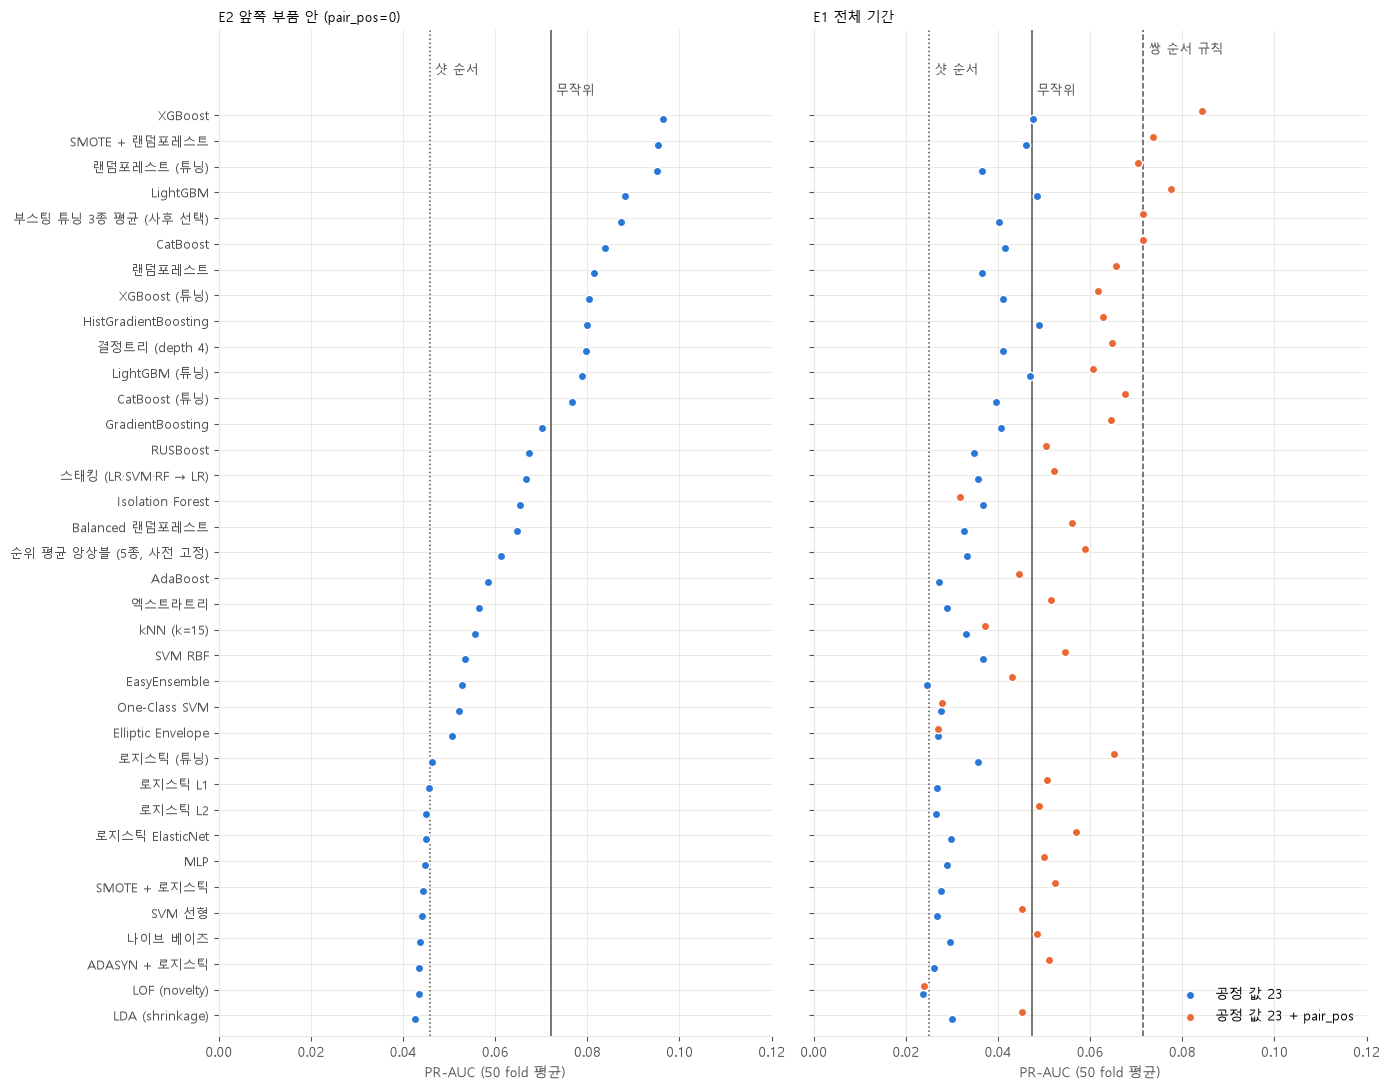

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 11), sharey=True)
order = (summary[(summary['eval'] == EVALS[1]) & (summary['features'] == '공정 값 23')]
         .sort_values('PR-AUC_mean')['model'].tolist())
y = np.arange(len(order))
for ax, ev in zip(axes, [EVALS[1], EVALS[0]]):
    d = summary[summary['eval'] == ev]
    for feat, color, dy in [('공정 값 23', C_MAIN, -0.15), ('공정 값 23 + pair_pos', C_SUB, 0.15)]:
        v = d[d['features'] == feat].set_index('model')['PR-AUC_mean'].reindex(order)
        if v.notna().any():
            ax.scatter(v.values, y + dy, s=36, color=color, label=feat, zorder=3, edgecolor='white', linewidth=1)
    base = d[d['family'] == '기준선'].set_index('model')['PR-AUC_mean']
    lines = [('[기준] 무작위', ' 무작위', '-'), ('[기준] 샷 순서', ' 샷 순서', ':'), ('[기준] 쌍 순서 규칙', ' 쌍 순서 규칙', '--')]
    for k, (name, label, ls) in enumerate([l for l in lines if l[0] in base.index]):
        ax.axvline(base[name], color=C_INK, linestyle=ls, linewidth=1.1)
        ax.text(base[name], len(order) - 0.3 + 0.8 * k, label, color=C_INK, fontsize=9, va='bottom')   # 가까워도 겹치지 않게 한 줄씩 위
    ax.set_title(ev, loc='left')
    ax.set_xlabel('PR-AUC (50 fold 평균)')
    ax.set_xlim(0, round(summary['PR-AUC_mean'].max() * 1.25, 2))
axes[0].set_yticks(y, order, fontsize=9)
axes[0].set_ylim(-0.8, len(order) + 2.3)
axes[1].legend(loc='lower right', frameon=False)
plt.tight_layout()
Path('outputs/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('outputs/figures/model_prauc.png', dpi=150, bbox_inches='tight')
plt.show()

### 읽는 법과 요약

**E2 앞쪽 부품 안 (판정용)**

| | PR-AUC | Recall@10% | Recall@20% | Recall@30% | 검사율@재현율0.9 | 검사율@재현율1 |
|---|---|---|---|---|---|---|
| [기준] 무작위 | 0.072 | 0.09 | 0.19 | 0.30 | 91% | 96% |
| [기준] 샷 순서 | 0.046 | 0.01 | 0.12 | 0.26 | 86% | 97% |
| 최고: XGBoost | 0.096 | 0.17 | 0.28 | 0.40 | 88% | 93% |
| 랜덤포레스트 (튜닝) | 0.095 | 0.15 | 0.25 | 0.34 | 84% | 91% |

- 부스팅·랜덤포레스트 계열이 무작위보다 명목상 조금 높지만(PR-AUC 0.08~0.10 vs 0.07), **fold 간 표준편차(0.04~0.07) 안**이다. ROC-AUC도 0.53~0.56에 그친다.
- 검사율@재현율0.9는 가장 낮은 모델도 81~82%(EasyEnsemble·엑스트라트리·HistGradientBoosting)로 무작위 91%와 큰 차이가 없다. **앞쪽 부품 안에서 공정 값으로 검사량을 줄일 여지는 거의 없다.**
- 선형 모델·나이브 베이즈·LDA는 ROC-AUC 0.39~0.43으로 오히려 무작위보다 낮다. 신호가 없을 때 소표본 교차검증에서 흔히 나타나는 현상이다.
- 이상탐지(학습 fold 양품만 학습)는 하위권이다 (검사율@재현율0.9 86~97%).

**E1 전체 기간 (참고)**
- 공정 값 23: 최고 PR-AUC 0.049로 무작위(0.047)와 같다.
- 공정 값 23 + `pair_pos`: 최고 XGBoost 0.084. 상승분은 쌍 순서 규칙(0.072)과 겹치고, 검사율@재현율0.9는 규칙(48%)이 모든 모델(56~96%)보다 낮다.
- 재현율 1.0 기준에서만 로지스틱(튜닝) + `pair_pos`가 69%로 규칙(82%)보다 낮지만, 뒤쪽 불량 2건에 기댄 결과다.

**계열별**
- **튜닝은 효과가 없었다.** E2에서 튜닝 버전이 기본 설정보다 낮다 (LightGBM 0.088 → 0.079, XGBoost 0.096 → 0.080). 학습 fold 불량 18~19개로 3-fold 튜닝을 하면 설정 비교 자체가 잡음이다.
- **앙상블도 단일 최고 모델을 넘지 못했다.** E2 사전 고정 5종 0.061, 사후 선택 부스팅 3종 0.087.
- RUSBoost는 학습 fold의 불량이 적어 E2에서 50개 중 46개 fold 학습에 실패해, 성공한 fold만의 평균이다.

## 5. 공정 값은 시간 정보 이상을 담고 있나 (E2)

앞쪽 부품 안에서 모델이 공정 값이 아니라 시간 흐름(샷 순서)을 배웠을 수 있다. **샷 순서만 넣은 모델**과 **샷 순서 + 공정 값을 넣은 모델**의 PR-AUC를 같은 fold에서 비교한다.
- **조건부 순열검정**: 샷을 연속 10개씩 묶고, 묶음 안에서만 샷끼리 공정 값을 뒤섞는다. 시간 흐름(10샷 단위)은 그대로 두고 "그 10샷 중 어느 샷이 불량인가"에 대한 공정 값 정보만 지운 기준이다. 실제 추가 기여가 이 기준의 95% 상한을 넘어야 공정 값이 시간 이상의 정보를 가진다고 본다.
- 계산량 때문에 순열검정은 2회 반복(10 fold) × 200번.

In [7]:
increment.round(3)

,PR-AUC 샷 순서만,PR-AUC 샷 순서 + 공정 값,추가 기여 (50 fold 평균),추가 기여가 양수인 fold 비율,추가 기여 (10 fold),순열 기준 평균 (10샷 창 안에서 섞음),순열 기준 95% 상한,순열 p
모델,,,,,,,,
로지스틱 L2,0.046,0.047,0.001,0.46,0.004,0.022,0.066,0.741
LightGBM,0.057,0.084,0.027,0.70,0.027,0.021,0.058,0.348


→ **앞쪽 부품 안에서도 공정 값이 시간 정보에 더하는 정보는 확인되지 않는다.**
- LightGBM: 샷 순서만 0.057 → 샷 순서 + 공정 값 0.084 (+0.027, 개선된 fold 70%). 그러나 10샷 창 안에서 공정 값을 섞은 기준의 95% 상한(+0.058)을 넘지 못한다 (p = 0.35).
- 로지스틱: +0.001 (개선된 fold 46%, p = 0.74).
- 즉 E2에서 부스팅 계열이 무작위보다 조금 높게 나온 것도, 공정 값에 불량 정보가 있다고 말할 근거는 되지 못한다.

> 참고: 이 표의 "샷 순서만" PR-AUC는 모델이 샷 번호를 학습한 결과이고 동점 처리 방식도 달라서, 기준선 행과 직접 비교하지 않는다. 비교는 같은 표 안에서만 한다.

## 6. 결론

**성능 (주 지표, E2 앞쪽 부품 안 = 판정용)**
1. 36개 모델 중 최고는 **XGBoost (기본 설정)**: PR-AUC 0.096 ± 0.061, Recall@10/20/30% = 0.17 / 0.28 / 0.40, 검사율@재현율0.9 = 88%.
2. 무작위(PR-AUC 0.072, 검사율@재현율0.9 91%)를 fold 간 편차 이상으로 넘는 모델은 없다. 조건부 순열검정에서도 공정 값의 추가 정보는 유의하지 않다 (LightGBM p = 0.35).
3. 튜닝·앙상블·불균형 샘플링·이상탐지는 기본 설정 부스팅을 넘지 못했다. 불량 23개로는 복잡한 방법이 더하는 이득보다 추정 잡음이 크다.

**손익 분석용 (검사율@재현율)**
- E2: 앞쪽 부품 안에서 재현율 0.9를 얻으려면, 가장 나은 모델로도 앞쪽 부품의 81~82%를 검사해야 한다 (무작위 91%) → 앞쪽 부품은 사실상 전수 검사.
- E1: 쌍 순서 규칙이 재현율 0.9에 검사 48%(앞쪽 부품 전수)로 가장 효율적이다. 공정 값 + `pair_pos` 모델은 56~96%.
- 따라서 운영안은 `RG33.ipynb` 7-4와 같다: **앞쪽 부품 전수 검사 + 뒤쪽은 ROI에 맞춘 표본 검사**.

**계획 기준 판정**
- "모델로 성능 끌어올리기": **실패**. 36개 모델 모두 E2에서 무작위, E1에서 쌍 순서 규칙을 넘지 못한다. 모델을 바꾸는 것으로는 더 끌어올리기 어렵다.
- 다음 단계는 데이터 쪽이다.
  - **신규 데이터 1순위**: KAMP 원본 1차 가공 데이터(`TimeStamp`, `PART_NAME`) — 쌍 순서가 부품 위치(LH/RH)인지 확인해 해석 A/B를 확정한다.
  - **캐비티별 센서**(금형 내압·온도) — 현재 공정 값은 한 샷의 두 부품이 공유해, 원리적으로 두 부품을 가를 수 없다.
  - **TabPFN**: 라이선스 동의·로그인 후 `model_zoo.py`에 추가하면 같은 방식으로 비교할 수 있다.

**해석 B (쌍 순서 = 검사 결과 기록 순서)일 때**
- `pair_pos`를 쓸 수 없고, 공정 값만으로는 E1·E2 모두 무작위 수준 → **전수검사 유지**.

**보고용 참고**
- 최종 후보: 쌍 순서 규칙 (해석 A). 모델을 쓴다면 XGBoost (기본 설정, 공정 값 + `pair_pos`) — 단 규칙보다 낫다는 근거는 없다.
- 결과표: `outputs/tables/model_summary.csv` (전 모델·전 지표 평균·표준편차), fold별 `model_folds.csv`, 반복별 `model_inspection.csv`, 추가 기여 `time_increment.csv`. 그림: `outputs/figures/model_prauc.png`.